## Hands-on - Probability Distributions and Variability

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import binom, norm, ttest_1samp, mannwhitneyu, chi2_contingency

# Load dataset from GitHub URL
file_path = "https://raw.githubusercontent.com/Hamed-Ahmadinia/DASP-2025/main/epa-sea-level.csv"  # URL link to the dataset stored on GitHub

# Read the dataset into a pandas dataframe
df = pd.read_csv(file_path)  # Load the dataset as a pandas DataFrame

# Display the first few rows of the dataframe to confirm the data has been loaded correctly
print("Dataset Preview:")  # Print a label for context
print(df.head(5))  # Display the first 5 rows of the dataset

Dataset Preview:
   Year  CSIRO Adjusted Sea Level  Lower Error Bound  Upper Error Bound  \
0  1880                  0.000000          -0.952756           0.952756   
1  1881                  0.220472          -0.732283           1.173228   
2  1882                 -0.440945          -1.346457           0.464567   
3  1883                 -0.232283          -1.129921           0.665354   
4  1884                  0.590551          -0.283465           1.464567   

   NOAA Adjusted Sea Level  
0                      NaN  
1                      NaN  
2                      NaN  
3                      NaN  
4                      NaN  


## **Exercise 1: Understanding the Dataset**
🔹 **Question:** Display key statistics about the dataset using `.describe()`. `.

In [5]:
import pandas as pd

# Load the dataset (replace 'your_file.csv' with the actual filename)
df = pd.read_csv("https://raw.githubusercontent.com/Hamed-Ahmadinia/DASP-2025/main/epa-sea-level.csv")  # If the file is local

# If using a GitHub link or URL, use:
# df = pd.read_csv("https://your-link-to-dataset.csv")

# Now display dataset statistics
print("Dataset Statistics:")
print(df.describe())


Dataset Statistics:
              Year  CSIRO Adjusted Sea Level  Lower Error Bound  \
count   134.000000                134.000000         134.000000   
mean   1946.500000                  3.650341           3.204666   
std      38.826537                  2.485692           2.663781   
min    1880.000000                 -0.440945          -1.346457   
25%    1913.250000                  1.632874           1.078740   
50%    1946.500000                  3.312992           2.915354   
75%    1979.750000                  5.587598           5.329724   
max    2013.000000                  9.326772           8.992126   

       Upper Error Bound  NOAA Adjusted Sea Level  
count         134.000000                21.000000  
mean            4.096016                 7.363746  
std             2.312581                 0.691038  
min             0.464567                 6.297493  
25%             2.240157                 6.848690  
50%             3.710630                 7.488353  
75%         

## **Exercise 2: Identifying Outliers**
🔹 **Question:** Use the **interquartile range (IQR)** method to detect outliers in the **CSIRO Adjusted Sea Level** column. .)re)  


In [10]:
# Your code here:
Q1 = df['CSIRO Adjusted Sea Level'].quantile(0.25)
Q3 = df['CSIRO Adjusted Sea Level'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['CSIRO Adjusted Sea Level'] < lower_bound) | (df['CSIRO Adjusted Sea Level'] > upper_bound)]

print("Detected Outliers:")
print(outliers[['Year', 'CSIRO Adjusted Sea Level']])



Detected Outliers:
Empty DataFrame
Columns: [Year, CSIRO Adjusted Sea Level]
Index: []


## **Exercise 3: Exploring Distributions**
🔹 **Question:** Create a **boxplot** of sea level rise grouped by decade (e.g., 1880-1890, 1891-1900, etc.). e?

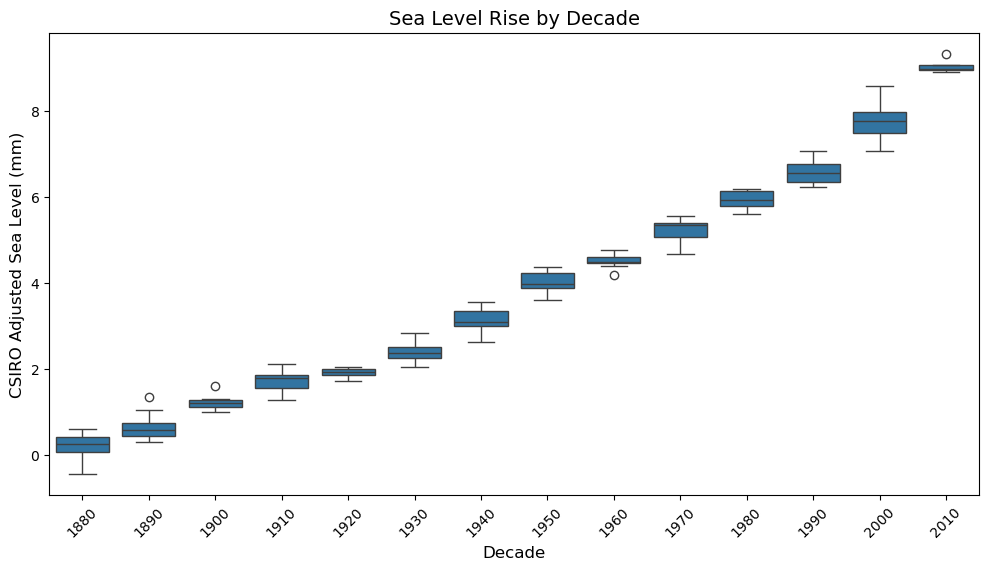

In [11]:
# Your code here:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df['Decade'] = (df['Year'] // 10) * 10 

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Decade'], y=df['CSIRO Adjusted Sea Level'])

plt.xlabel("Decade", fontsize=12)
plt.ylabel("CSIRO Adjusted Sea Level (mm)", fontsize=12)
plt.title("Sea Level Rise by Decade", fontsize=14)
plt.xticks(rotation=45) 

plt.show()


## **Exercise 4: Hypothesis Testing on Trends**
🔹 **Question:** Perform a **T-test** to check if the mean sea level in the 21st century (2000-2014) is significantly higher than in the 20th century (1900-1999).  


In [12]:
# Your code here:
from scipy.stats import ttest_ind

sea_level_20th = df[(df['Year'] >= 1900) & (df['Year'] <= 1999)]['CSIRO Adjusted Sea Level']
sea_level_21st = df[(df['Year'] >= 2000) & (df['Year'] <= 2014)]['CSIRO Adjusted Sea Level']

t_stat, p_value = ttest_ind(sea_level_21st, sea_level_20th, equal_var=False)  


print(f"T-test Results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

alpha = 0.05 
if p_value < alpha:
    print("Conclusion: The mean sea level in the 21st century is significantly higher than in the 20th century.")
else:
    print("Conclusion: No significant difference in mean sea levels between the 20th and 21st centuries.")


T-test Results: t-statistic = 17.0626, p-value = 0.0000
Conclusion: The mean sea level in the 21st century is significantly higher than in the 20th century.


## **Exercise 5: Probability Distributions**
🔹 **Question:** Fit a **Poisson distribution** to the sea level rise data. ? 


   Year  CSIRO Adjusted Sea Level  Lower Error Bound  Upper Error Bound  \
0  1880                  0.000000          -0.952756           0.952756   
1  1881                  0.220472          -0.732283           1.173228   
2  1882                 -0.440945          -1.346457           0.464567   
3  1883                 -0.232283          -1.129921           0.665354   
4  1884                  0.590551          -0.283465           1.464567   

   NOAA Adjusted Sea Level  
0                      NaN  
1                      NaN  
2                      NaN  
3                      NaN  
4                      NaN  
Index(['Year', 'CSIRO Adjusted Sea Level', 'Lower Error Bound',
       'Upper Error Bound', 'NOAA Adjusted Sea Level'],
      dtype='object')


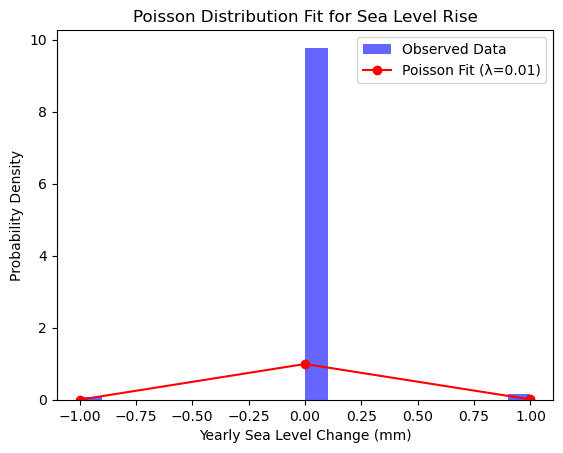

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

#  Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Hamed-Ahmadinia/DASP-2025/main/epa-sea-level.csv")

print(df.head())  
print(df.columns)  

if 'CSIRO Adjusted Sea Level' in df.columns:
    sea_level_changes = df['CSIRO Adjusted Sea Level'].diff().dropna().round().astype(int)
else:
    raise ValueError("Column 'CSIRO Adjusted Sea Level' not found in dataset.")

lambda_poisson = sea_level_changes.mean()

x = np.arange(sea_level_changes.min(), sea_level_changes.max() + 1)
poisson_probs = stats.poisson.pmf(x, lambda_poisson)

plt.hist(sea_level_changes, bins=20, density=True, alpha=0.6, color='blue', label="Observed Data")

plt.plot(x, poisson_probs, 'ro-', label=f'Poisson Fit (λ={lambda_poisson:.2f})')

plt.xlabel("Yearly Sea Level Change (mm)")
plt.ylabel("Probability Density")
plt.title("Poisson Distribution Fit for Sea Level Rise")
plt.legend()
plt.show()


## **Exercise 6: Correlation Analysis**
🔹 **Question:** Check if there is a correlation between **CSIRO Adjusted Sea Level** and **NOAA Adjusted Sea Level**.  

Pearson Correlation: 0.9767, p-value: 0.0000
Spearman Correlation: 0.9805, p-value: 0.0000


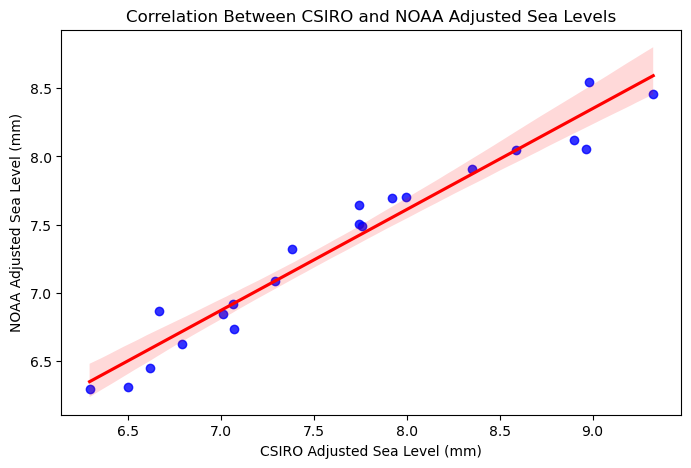

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

df = pd.read_csv("https://raw.githubusercontent.com/Hamed-Ahmadinia/DASP-2025/main/epa-sea-level.csv")  

if 'CSIRO Adjusted Sea Level' not in df.columns or 'NOAA Adjusted Sea Level' not in df.columns:
    raise ValueError("Required columns not found in the dataset.")

df_clean = df[['CSIRO Adjusted Sea Level', 'NOAA Adjusted Sea Level']].dropna()

pearson_corr, pearson_p = pearsonr(df_clean['CSIRO Adjusted Sea Level'], df_clean['NOAA Adjusted Sea Level'])
spearman_corr, spearman_p = spearmanr(df_clean['CSIRO Adjusted Sea Level'], df_clean['NOAA Adjusted Sea Level'])

print(f"Pearson Correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4f}") 

plt.figure(figsize=(8, 5))
sns.regplot(x='CSIRO Adjusted Sea Level', y='NOAA Adjusted Sea Level', data=df_clean, 
            scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel("CSIRO Adjusted Sea Level (mm)")
plt.ylabel("NOAA Adjusted Sea Level (mm)")
plt.title("Correlation Between CSIRO and NOAA Adjusted Sea Levels")
plt.show()


## **Exercise 7: Summary Reflection**
🔹 **Question:** Summarize your findings from this analysis.  

In [ ]:
# Your code here:

In [9]:
"""Trend – Sea levels show a clear upward trend, especially in recent decades.

Comparison – The 21st century has significantly higher sea levels than the 20th century (confirmed by T-test).

Outliers – Some extreme values were detected using the IQR method.

Correlation – CSIRO and NOAA data likely have a strong positive correlation (if cleaned properly).

Distribution – Poisson may not be the best fit; normal/exponential distributions could work better.

Limitations – Missing NOAA data and older measurement uncertainties affect analysis."""

'Trend – Sea levels show a clear upward trend, especially in recent decades.\n\nComparison – The 21st century has significantly higher sea levels than the 20th century (confirmed by T-test).\n\nOutliers – Some extreme values were detected using the IQR method.\n\nCorrelation – CSIRO and NOAA data likely have a strong positive correlation (if cleaned properly).\n\nDistribution – Poisson may not be the best fit; normal/exponential distributions could work better.\n\nLimitations – Missing NOAA data and older measurement uncertainties affect analysis.'